# 0. set up the notebook environment

In [1]:
import os, sys, platform
node = platform.node()
if "arctrd" in node:
    ROOT_DIR = os.getcwd()
else:
    ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(ROOT_DIR)

from omegaconf import OmegaConf, DictConfig
import numpy as np
import pandas as pd
import torch 
import os
import time

from src.settings import LOGS_ROOT, DATA_ROOT
LOGS_ROOT, DATA_ROOT

('/data/users2/ppopov1/DECIFRA/assets/logs', '/data/users2/ppopov1/datasets')

# 1. load UKB and holdout FBIRN data

In [2]:
from src.datasets.ukb_hold import load_data_hold as load_ukb_pretrain

UKB_DATADICT, demo_df = load_ukb_pretrain(
    file_path=os.path.join(DATA_ROOT, "ukb_ica/ukb_data_hold.npz"),
    demo_path=os.path.join(DATA_ROOT, "ukb_ica/demographics_legend_hold.csv"),
)

UKB_DATA = UKB_DATADICT['data']
print("Available data in ukb datadict:",UKB_DATADICT.keys())
# prepare train and validation sets
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(UKB_DATA, test_size=0.2, random_state=42)

Available data in ukb datadict: dict_keys(['data', 'sexes', 'ages', 'age_bins'])


In [3]:
from src.datasets.fbirn import load_data_hold as load_fbirn_hold

FBIRN_DATADICT, fbirn_demo_df = load_fbirn_hold()

FBIRN_DATA = FBIRN_DATADICT['data']
print("Available data in fbirn datadict:",FBIRN_DATADICT.keys())
print("FBIRN data shape:", FBIRN_DATA.shape)

Available data in fbirn datadict: dict_keys(['data', 'diags', 'sexes', 'ages', 'age_bins'])
FBIRN data shape: (16, 140, 53)


# test if it works

In [51]:
# set model config

from src.models.DECIFRA import default_HPs

cfg = {
    "data_info": {
        "feature_size": UKB_DATA.shape[2],
        "n_classes": 2,
        }
    }
cfg = OmegaConf.create(cfg)

model_cfg = default_HPs(cfg)

print(OmegaConf.to_yaml(model_cfg))

single_embedder: true
single_GRU: true
rnn:
  input_embedding_size: 16
  hidden_size: 16
btp:
  hidden_dim: 16
single_predictor: true
loss:
  threshold: 0.01
  sp_weight: 1.0
  forecast_weight: 1.0
  prediction_delay: 0
  prediction_depth: 1
  weighted_change: false
lr: 0.0001
load_pretrained: false
pretrained_path: null
pretraining: true
input_size: 53
output_size: 2



In [ ]:
# test if it works

from src.trainers.BasicPreTrainer import BasicPreTrainer
from src.models.DECIFRA import DECIFRA
import time

device = torch.device("cuda")

model = DECIFRA(model_cfg)
optimizer = model.get_optimizer()

train_dataloader = model.prepare_pretraining_dataloader(train_data[:100], shuffle=True)
val_dataloader = model.prepare_pretraining_dataloader(val_data[:20], shuffle=False)

utc_string = time.strftime("%m%d-%H%M%S", time.gmtime())
save_path = f"0_test_{model.__class__.__name__}_{utc_string}"
save_path = os.path.join(LOGS_ROOT, save_path)

trainer = BasicPreTrainer(
    cfg=cfg,
    model_cfg=model_cfg,
    model=model,
    optimizer=optimizer,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    epochs=10,
    save_path=save_path,
)

train_logs = trainer.run()

# pretraining

In [4]:
# set model config

from src.models.DECIFRA import default_HPs

cfg = {
    "data_info": {
        "feature_size": UKB_DATA.shape[2],
        "n_classes": 2,
        }
    }
cfg = OmegaConf.create(cfg)

model_cfg = default_HPs(cfg)

print(OmegaConf.to_yaml(model_cfg))

single_embedder: true
single_GRU: true
rnn:
  input_embedding_size: 16
  hidden_size: 16
btp:
  hidden_dim: 16
single_predictor: true
loss:
  threshold: 0.01
  sp_weight: 1.0
  forecast_weight: 1.0
  prediction_delay: 0
  prediction_depth: 1
  weighted_change: false
lr: 0.001
load_pretrained: false
pretrained_path: null
pretraining: true
input_size: 53
output_size: 2



In [ ]:
# train
from src.trainers.BasicPreTrainer import BasicPreTrainer
from src.models.DECIFRA import DECIFRA
import torch
device = torch.device("cuda")

for i in range(30):
    model = DECIFRA(model_cfg)
    model = model.to(device)
    optimizer = model.get_optimizer()
    model.train()

    train_dataloader = model.prepare_pretraining_dataloader(train_data, shuffle=True)
    val_dataloader = model.prepare_pretraining_dataloader(val_data, shuffle=False)

    utc_string = time.strftime("%m%d-%H%M%S", time.gmtime())
    save_path = f"1_pretrain_{model.__class__.__name__}/{i:02d}"
    save_path = os.path.join(LOGS_ROOT, save_path)

    trainer = BasicPreTrainer(
        cfg=cfg,
        model_cfg=model_cfg,
        model=model,
        optimizer=optimizer,
        train_loader=train_dataloader,
        val_loader=val_dataloader,
        epochs=200,
        save_path=save_path,
    )

    train_logs = trainer.run()

## train LSTM for signal prediction -- for comparison

In [5]:
# set model config

from src.models.LSTM_forecaster import default_HPs

cfg = {
    "data_info": {
        "feature_size": UKB_DATA.shape[2],
        "n_classes": 2,
        }
    }
cfg = OmegaConf.create(cfg)

model_cfg = default_HPs(cfg)

print(OmegaConf.to_yaml(model_cfg))

input_size: 53
output_size: 2



In [ ]:
# train
from src.trainers.BasicPreTrainer import BasicPreTrainer
from src.models.LSTM_forecaster import LSTM
import torch
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model = LSTM(model_cfg)
model = model.to(device)
optimizer = model.get_optimizer()
model.train()

train_dataloader = model.prepare_pretraining_dataloader(train_data, shuffle=True)
val_dataloader = model.prepare_pretraining_dataloader(val_data, shuffle=False)

utc_string = time.strftime("%m%d-%H%M%S", time.gmtime())
save_path = f"1_pretrain_{model.__class__.__name__}/00/"
save_path = os.path.join(LOGS_ROOT, save_path)

trainer = BasicPreTrainer(
    cfg=cfg,
    model_cfg=model_cfg,
    model=model,
    optimizer=optimizer,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    epochs=100,
    save_path=save_path,
)

train_logs = trainer.run()

# plot pretraining curves

In [4]:
import matplotlib.pyplot as plt

def get_csvs(path, tag=None):
    all_logs = []

    for run in os.listdir(path):
        try:
            logs_path = os.path.join(path, run, "train_logs.csv")
            df = pd.read_csv(logs_path)
            df.insert(1, 'exp', run)

            # if there is more than 10 epochs past 50 in the top-50 val losses, mark as strange
            strange = False
            if (df["val_loss"].iloc[50:].values > df['val_loss'].nlargest(50).iloc[-1]).sum() > 5:
                strange = True

            # # if last 10 val_losses are not one of the lowest, mark the run as strange
            # strange = False
            # if df["val_loss"].values[-10:].min() > df["val_loss"].values[:-10].min():
            #     strange = True

            df.insert(2, 'strange', strange)

            all_logs.append(df)
        except:
            continue

    all_logs = pd.concat(all_logs)
    if tag is None:
        tag = os.path.basename(path)
    all_logs.insert(1, 'tag', tag)

    return all_logs

def plot_exps_in_df(df, losses=["val_loss"]):

    for i, loss in enumerate(losses):
        plt.figure(figsize=(8,6))
        for run in df["exp"].unique():
            run_df = df[df["exp"]==run]
            plt.plot(run_df[loss].values, alpha=0.3)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title(loss)
        plt.show()

/tmp/ipykernel_1721970/466807611.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


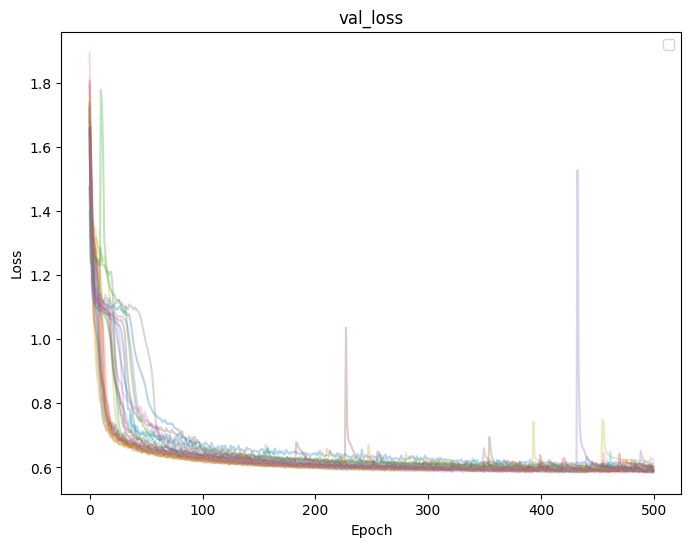

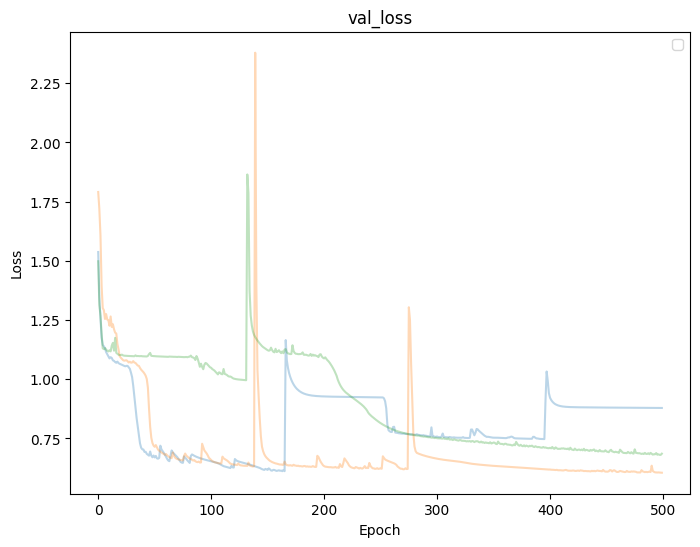

Strange runs: ['06' '17' '21'], 
Normal runs: ['00' '01' '02' '03' '04' '05' '09' '08' '07' '10' '11' '12' '13' '14'
 '15' '16' '18' '19' '20' '22' '23' '24' '25' '26' '27' '28' '29']


In [21]:
vanilla_logs = get_csvs("/data/users2/ppopov1/DECIFRA/assets/logs/1_pretrain_DECIFRA", tag="vanilla_DECIFRA")
plot_exps_in_df(vanilla_logs[vanilla_logs["strange"]==False])
plot_exps_in_df(vanilla_logs[vanilla_logs["strange"]==True])

print(f"Strange runs: {vanilla_logs[vanilla_logs['strange']==True]['exp'].unique()}, \n"
      f"Normal runs: {vanilla_logs[vanilla_logs['strange']==False]['exp'].unique()}")

/tmp/ipykernel_1721970/466807611.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


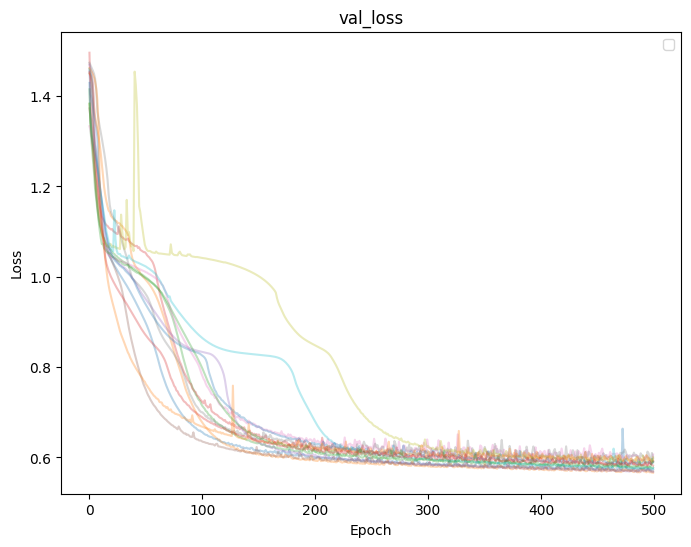

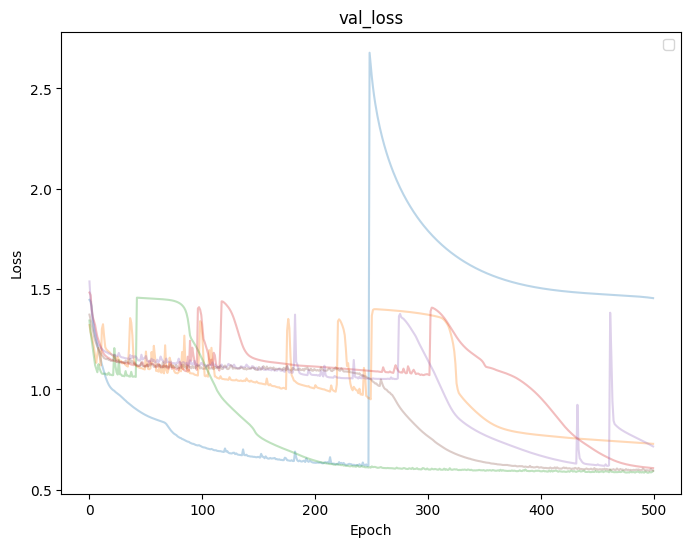

In [6]:
sp05_logs = get_csvs("/data/users2/ppopov1/DECIFRA/assets/logs/1_pretrain_DECIFRA_sp05_LR01", tag="sp05")
plot_exps_in_df(sp05_logs[sp05_logs["strange"]==False])
plot_exps_in_df(sp05_logs[sp05_logs["strange"]==True])

/tmp/ipykernel_1721970/466807611.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


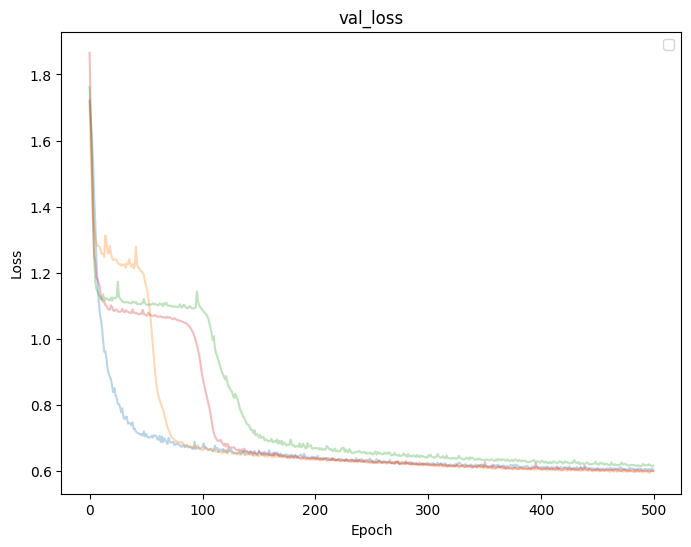

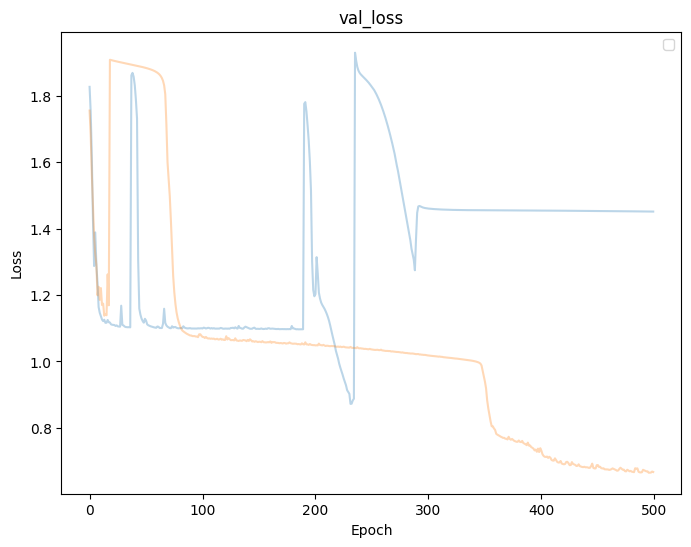

In [7]:
lr4_logs = get_csvs("/data/users2/ppopov1/DECIFRA/assets/logs/1_pretrain_DECIFRA_LR04", tag="lr4")
plot_exps_in_df(lr4_logs[lr4_logs["strange"]==False])
plot_exps_in_df(lr4_logs[lr4_logs["strange"]==True])

/tmp/ipykernel_1721970/466807611.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


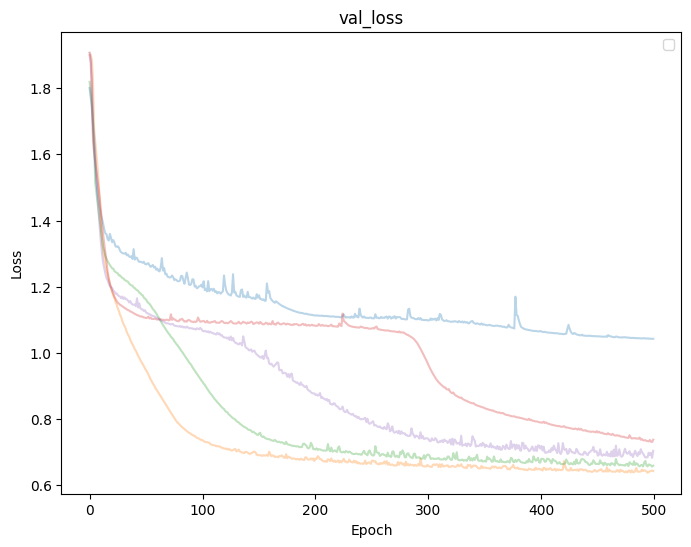

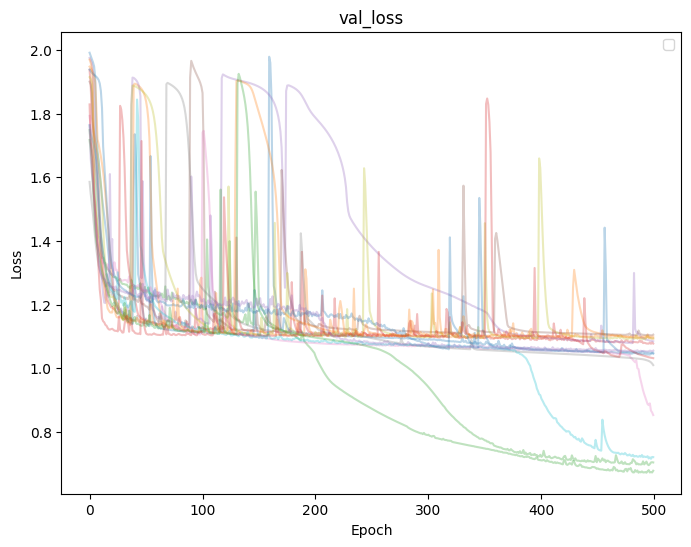

In [8]:
lr10_logs = get_csvs("/data/users2/ppopov1/DECIFRA/assets/logs/1_pretrain_DECIFRA_LR01", tag="lr10")
plot_exps_in_df(lr10_logs[lr10_logs["strange"]==False])
plot_exps_in_df(lr10_logs[lr10_logs["strange"]==True])

/tmp/ipykernel_3198168/21863078.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


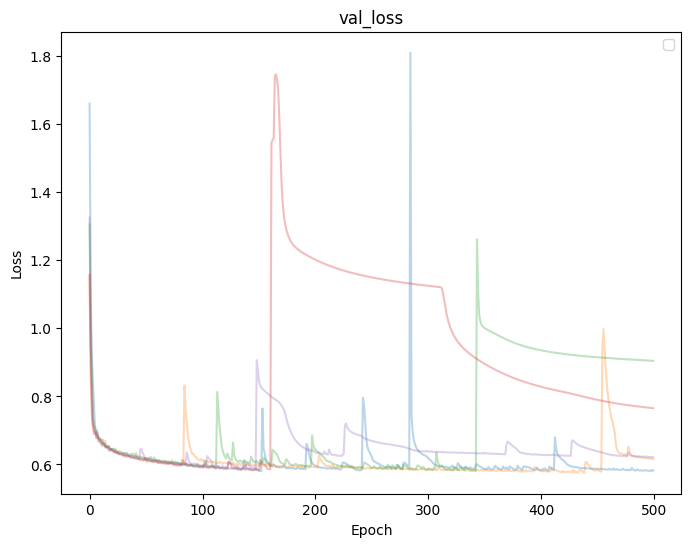

In [5]:
# BIG LOGS
big_logs = get_csvs("/data/users2/ppopov1/DECIFRA/assets/logs/1_pretrain_DECIFRA_big", tag="big_DECIFRA")
plot_exps_in_df(big_logs)

# inspect matrices from pretrained models

In [13]:
from src.models.DECIFRA import default_HPs
from src.models.DECIFRA import DECIFRA

def derive_matrices_for_checkpoint(ckpt_path):
    cfg = {
        "data_info": {
            "feature_size": UKB_DATA.shape[2],
            "n_classes": 2,
            }
        }
    cfg = OmegaConf.create(cfg)
    model_cfg = default_HPs(cfg)

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

    model = DECIFRA(model_cfg)
    fbirn_input = torch.tensor(FBIRN_DATA, dtype=torch.float32).to(device)

    ckpt = torch.load(ckpt_path, map_location='cpu')
    state_dict = ckpt.get('state_dict', ckpt)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    _, output = model(fbirn_input)

    matrices = output["matrices"].detach().cpu().numpy()
    return matrices

def derive_matrices_for_model(model_cfg, ckpt_path):
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

    model = DECIFRA(model_cfg)
    fbirn_input = torch.tensor(FBIRN_DATA, dtype=torch.float32).to(device)

    ckpt = torch.load(ckpt_path, map_location='cpu')
    state_dict = ckpt.get('state_dict', ckpt)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    _, output = model(fbirn_input)

    matrices = output["matrices"].detach().cpu().numpy()
    return matrices

In [14]:
# BIG MODEL
exp_path = "/data/users2/ppopov1/DECIFRA/assets/logs/1_pretrain_DECIFRA_big"

fbirn_outputs = {}
for run in os.listdir(exp_path):
    run_path = os.path.join(exp_path, run)

    # check if train_logs.csv exists
    if not os.path.isfile(os.path.join(run_path, "train_logs.csv")):
        continue

    model_cfg_path = os.path.join(run_path, "model_config.yaml")
    model_cfg = OmegaConf.load(model_cfg_path)

    # get best model index from .txt file
    best_model_idx = pd.read_csv(os.path.join(run_path, "best_epoch.txt"), header=None).iloc[0, 0]

    ckpt_path = os.path.join(run_path, f"checkpoints/model_{best_model_idx}.pt")

    matrices = derive_matrices_for_model(model_cfg, ckpt_path)

    np.save(os.path.join(run_path, "fbirn_matrices.npy"), matrices)
    fbirn_outputs[run] = matrices

In [17]:
exp_path = "/data/users2/ppopov1/DECIFRA/assets/logs/1_pretrain_DECIFRA_big"

for key, matrix in fbirn_outputs.items():
    save_path = os.path.join(exp_path, f"_images/{key}.png")
    plot_combined_matrices(matrix, save_path, n_samples=1)

In [28]:
exp_path = "/data/users2/ppopov1/DECIFRA/assets/logs/1_pretrain_DECIFRA"

fbirn_outputs = {}
for run in os.listdir(exp_path):
    run_path = os.path.join(exp_path, run)

    # get best model index from .txt file
    best_model_idx = pd.read_csv(os.path.join(run_path, "best_epoch.txt"), header=None).iloc[0, 0]

    ckpt_path = os.path.join(run_path, f"checkpoints/model_{best_model_idx}.pt")

    matrices = derive_matrices_for_checkpoint(ckpt_path)

    np.save(os.path.join(run_path, "fbirn_matrices.npy"), matrices)
    fbirn_outputs[run] = matrices

In [15]:
import matplotlib.pyplot as plt
import numpy as np
def plot_combined_matrices(matrices, save_path, n_samples=5, n_time=5):
    if n_samples == -1:
         n_samples = matrices.shape[0]
         
    # Normalize the range for the seismic colormap to center around 0
    abs_max = np.max(np.abs(matrices[:n_samples, 50:(n_time+50)]))
    vmin, vmax = -abs_max, abs_max  # Centering colormap around 0

    # Determine the size of individual matrices
    matrix_size = matrices[0, 0].shape[0]

    # Create a large matrix to hold all the smaller matrices with padding
    combined_matrix = np.full(
        ((matrix_size + 1) * n_samples - 1, (matrix_size + 1) * n_time - 1),
        0.1
    )

    for i in range(n_samples):
        for j in range(n_time):
            matrix = matrices[i, 50 + j]  # Convert to NumPy
            start_row = i * (matrix_size + 1)
            start_col = j * (matrix_size + 1)
            combined_matrix[start_row:start_row + matrix_size, start_col:start_col + matrix_size] = matrix

    # Plot the combined matrix
    # dpi=1
    dpi=4
    figsize = combined_matrix.shape[1] * dpi, combined_matrix.shape[0] * dpi  # Match the figure size to the array dimensions (pixels)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)
    ax.imshow(combined_matrix, cmap="seismic", vmin=vmin, vmax=vmax, interpolation='none')
    plt.savefig(save_path, dpi=dpi)
    plt.close()

def plot_mean_matrices(matrices, save_path, n_samples=5):
    ### also plot mean-over-time matrices ###
    if n_samples == -1:
         n_samples = matrices.shape[0]
    # Calculate the mean over time for each sample
    mean_matrices = matrices[:n_samples].mean(dim=1)

    # Normalize the range for the seismic colormap to center around 0
    abs_max = mean_matrices.abs().max().item()
    vmin, vmax = -abs_max, abs_max  # Centering colormap around 0

    matrix_size = matrices[0, 0].shape[0]
    combined_matrix = np.full(
        ((matrix_size + 1) * n_samples - 1, matrix_size),
        0.1
    )
    for i in range(n_samples):
            matrix = mean_matrices[i].cpu().detach().numpy()  # Convert to NumPy
            start_row = i * (matrix_size + 1)
            combined_matrix[start_row:start_row + matrix_size, :] = matrix
            
    # Plot the combined matrix
    dpi=4
    figsize = combined_matrix.shape[1] * dpi, combined_matrix.shape[0] * dpi  # Match the figure size to the array dimensions (pixels)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)
    ax.imshow(combined_matrix, cmap="seismic", vmin=vmin, vmax=vmax, interpolation='none')
    plt.savefig(save_path, dpi=dpi)
    plt.close()

In [33]:
exp_path = "/data/users2/ppopov1/DECIFRA/assets/logs/1_pretrain_DECIFRA"

for key, matrix in fbirn_outputs.items():
    save_path = os.path.join(exp_path, f"_images/{key}.png")
    plot_combined_matrices(matrix, save_path, n_samples=1)
    